<a href="https://colab.research.google.com/github/m0deko/HW_projects/blob/main/Hometasks/Base/HW1_Regression_with_inference_base.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Домашнее задание №1 (base). Часть 1**

В этом домашнем задании вам будет необходимо:
*  обучить модель регрессии для предсказания стоимости автомобилей;

**Максимальная оценка за дз**
> Оценка за первую часть домашки = $min(\text{ваш балл}, 7)$


**Примечание**

В каждой части оцениваются как код, **так и ответы на вопросы.**

Если нет одного и/или другого, то часть баллов за соответствующее задание снимается.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import seaborn as sns

random.seed(42)
np.random.seed(42)

Давайте зафиксируем важный момент.

**Задание 0 (0 баллов).**
Изучите и ответье на вопрос: для чего фиксируем сиды в домашках?

`Your answer here`

# **Часть 1 | EDA и визуализация**

Первая часть состоит из классических шагов EDA:

- Базовый EDA и обработка признаков (2.5 балла)
- Визуализации признаков и их анализ (1 балл)

Всего можно набрать 3.5 основных балла и 0.65 бонусных. Бонусные задания выделены как **Дополнительное задание/Бонус**. Вы можете выполнять их, чтобы в случае ошибок в основных задачах всё равно набрать за работу максимум. Кроме того, дополнительные задания позволяют вам углубить знания.

Призываем активно использовать их!

## **Простейший EDA и обработка признаков (2.5 балла)**

In [2]:
import pandas as pd
import numpy as np


In [3]:
df_train = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_train.csv')
df_test = pd.read_csv('https://raw.githubusercontent.com/Murcha1990/MLDS_ML_2022/main/Hometasks/HT1/cars_test.csv')

print("Train data shape:", df_train.shape)
print("Test data shape: ", df_test.shape)

Train data shape: (6999, 13)
Test data shape:  (1000, 13)


### **Задание 1 (0.5 балла)**

Вы уже встречались с pandas в первой половине семестра. Теперь будем постоянно (кроме некоторых случаев) использовать его для анализа данных и наслаивать навыки. Выполните операции, направленные на практику основных действий с `pandas`:

**0.1 балла**
- [ ] Отобразите 30 случайных строк тренировочного датасета.
- [ ] Отобразите первые 5 и последние 5 объектов тестового датасета
- [ ] Посмотрите, есть ли в датасете пропуски. Запишите/выведите названия колонок, для которых есть пропущенные значения
- [ ] Посмотрите, есть ли в данных явные дубликаты


**0.2 балла**
Ответьте на вопросы:
- [ ] Выводы о чем можно сделать, используя случайные/верхние/нижние строки? А о чем нельзя?
- [ ] Достаточно ли метода duplicated для анализа дубликатов? Почему?

**0.15 балла**
- [ ] Постройте дашборд, используя [ydata-profilling](https://github.com/ydataai/ydata-profiling)

In [4]:
from numpy.random import random_sample
RANDOM_STATE = 42

#1:
df_train.sample(random_state=RANDOM_STATE, n = 30)
df_test.head(5)
df_test.tail(5)
df_train.isna().sum()
df_train.columns[df_train.isna().any()]
# df_train[df_train.duplicated()]

#2:
# 1) Можно сделать вывод о типе объектов, составе колонок, небольшом наличии пропусков. Нельзя сделать выводы о распределении объектов, о возможных корреляциях между
# признаками, о наличии всех возможных типов в категориальных признаках.
# 2) Не достаточно, ибо возможны дубликаты с разными построчно объектами, но одинаковыми по контексту или возможен разный айдишник/прочий параметр не отвечающий за обучение
# модели

Index(['mileage', 'engine', 'max_power', 'torque', 'seats'], dtype='object')

In [5]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6999 entries, 0 to 6998
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           6999 non-null   object 
 1   year           6999 non-null   int64  
 2   selling_price  6999 non-null   int64  
 3   km_driven      6999 non-null   int64  
 4   fuel           6999 non-null   object 
 5   seller_type    6999 non-null   object 
 6   transmission   6999 non-null   object 
 7   owner          6999 non-null   object 
 8   mileage        6797 non-null   object 
 9   engine         6797 non-null   object 
 10  max_power      6803 non-null   object 
 11  torque         6796 non-null   object 
 12  seats          6797 non-null   float64
dtypes: float64(1), int64(3), object(9)
memory usage: 711.0+ KB


In [6]:
!pip install https://github.com/pandas-profiling/pandas-profiling/archive/master.zip -q

     / 17.9 MB 25.7 MB/s 0:00:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 296.7/296.7 kB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 57.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 679.7/679.7 kB 44.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 105.4/105.4 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 6.4 MB/s eta 0:00:00


In [7]:
from ydata_profiling import ProfileReport

/tmp/ipykernel_1026/44057814.py:1: DeprecationWarning: 
    `import ydata_profiling` is deprecated and will not receive more updates. 
    Please use `import data_profiling` instead.
    
  from ydata_profiling import ProfileReport


In [8]:
profile_report = ProfileReport(df_train, title='Pandas Report')
profile_report.to_file('Report.html')

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 29.20it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

Мы обнаружили пропуски. Давайте избавимся от них.

**(0.05 балла)**
- [ ] Заполните пропуски в столбцах медианами. Убедитесь, что после заполнения пропусков не осталось. Заполнение пропусков проводите для обоих наборов данных, если необходимо

**Важно!**

При заполнении пропусков и в тестовом, и тренировочном наборах данных вы определяетесь со стратегией предобработки пропущенных значений при потенциальной работе модели.

Так как в теоретическом случае вы не имеете доступа к тестовой выборке, то заполняемой значение (у нас — медиана) вы считаете про *тренировочному* набору данных и им же заполняете *тестовый*.

In [9]:
from sklearn import impute

mis_replacer = impute.SimpleImputer(strategy = "mean")

mask_cat = (df_train.dtypes=='object').values

df_real = df_train[df_train.columns[~mask_cat]]
df_cat = df_train[df_train.columns[mask_cat]]

df_real_fixed = pd.DataFrame(data=mis_replacer.fit_transform(df_real), columns=df_real.columns)

df_train_fixed = pd.concat([df_real_fixed, df_cat], axis = 1)

In [10]:
df_train_fixed

,year,selling_price,km_driven,seats,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
0,2014.0,450000.0,145500.0,5.0,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,2014.0,370000.0,120000.0,5.0,Skoda Rapid 1.5 TDI Ambition,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,2010.0,225000.0,127000.0,5.0,Hyundai i20 Sportz Diesel,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
3,2007.0,130000.0,120000.0,5.0,Maruti Swift VXI BSIII,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"
4,2017.0,440000.0,45000.0,5.0,Hyundai Xcent 1.2 VTVT E Plus,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6994,2013.0,320000.0,110000.0,5.0,Hyundai i20 Magna,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm
6995,2007.0,135000.0,119000.0,5.0,Hyundai Verna CRDi SX,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)"
6996,2009.0,382000.0,120000.0,5.0,Maruti Swift Dzire ZDi,Diesel,Individual,Manual,First Owner,19.3 kmpl,1248 CC,73.9 bhp,190Nm@ 2000rpm
6997,2013.0,290000.0,25000.0,5.0,Tata Indigo CR4,Diesel,Individual,Manual,First Owner,23.57 kmpl,1396 CC,70 bhp,140Nm@ 1800-3000rpm


### **Задание 2 (0.5 балла)**

На прошлом шаге вы рассмотрели дубликаты. Однако дубликат может быть связан с не только полным повторением информации в нескольких строках, но и частиным. Например, объект мог был внесен в базу данных с разным значением целевой переменной. В этом шаге займемся такими дублями!

**Ваши действия:**

- [ ] Посмотрите, есть ли в трейне объекты с одинаковым признаковым описанием (целевую переменную следует исключить). Если есть, то сколько? (0.1 балла)
- [ ] Отобразите такие объекты (0.15 балла)
- [ ] Удалите повторяющиеся строки. Если при одинаковом признаковом описании цены на автомобили отличаются, то оставьте первую строку по этому автомобилю (0.15 балла)
- [ ]  Обновите индексы строк таким образом, чтобы они шли от 0 без пропусков (0.1 балла)


In [11]:
X = df_train_fixed.drop(columns=['selling_price'])
y = df_train_fixed['selling_price']

In [12]:
#1:
X.duplicated().sum()
#2:
X[X.duplicated()]
#3:
mask = X.duplicated()
df_train_fixed_und = df_train_fixed[~mask]
df_train_fixed_und.reset_index(drop=True, inplace=True)


In [13]:
df_train_fixed_und

,year,selling_price,km_driven,seats,name,fuel,seller_type,transmission,owner,mileage,engine,max_power,torque
0,2014.0,450000.0,145500.0,5.0,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner,23.4 kmpl,1248 CC,74 bhp,190Nm@ 2000rpm
1,2014.0,370000.0,120000.0,5.0,Skoda Rapid 1.5 TDI Ambition,Diesel,Individual,Manual,Second Owner,21.14 kmpl,1498 CC,103.52 bhp,250Nm@ 1500-2500rpm
2,2010.0,225000.0,127000.0,5.0,Hyundai i20 Sportz Diesel,Diesel,Individual,Manual,First Owner,23.0 kmpl,1396 CC,90 bhp,22.4 kgm at 1750-2750rpm
3,2007.0,130000.0,120000.0,5.0,Maruti Swift VXI BSIII,Petrol,Individual,Manual,First Owner,16.1 kmpl,1298 CC,88.2 bhp,"11.5@ 4,500(kgm@ rpm)"
4,2017.0,440000.0,45000.0,5.0,Hyundai Xcent 1.2 VTVT E Plus,Petrol,Individual,Manual,First Owner,20.14 kmpl,1197 CC,81.86 bhp,113.75nm@ 4000rpm
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5835,2008.0,120000.0,191000.0,5.0,Hyundai Santro Xing GLS,Petrol,Individual,Manual,First Owner,17.92 kmpl,1086 CC,62.1 bhp,96.1Nm@ 3000rpm
5836,2013.0,260000.0,50000.0,5.0,Maruti Wagon R VXI BS IV with ABS,Petrol,Individual,Manual,Second Owner,18.9 kmpl,998 CC,67.1 bhp,90Nm@ 3500rpm
5837,2013.0,320000.0,110000.0,5.0,Hyundai i20 Magna,Petrol,Individual,Manual,First Owner,18.5 kmpl,1197 CC,82.85 bhp,113.7Nm@ 4000rpm
5838,2007.0,135000.0,119000.0,5.0,Hyundai Verna CRDi SX,Diesel,Individual,Manual,Fourth & Above Owner,16.8 kmpl,1493 CC,110 bhp,"24@ 1,900-2,750(kgm@ rpm)"


In [14]:
# assert df_train.shape == (5840, 13)

Отлично! Мы избавились от маленьких и явных проблем. Теперь перейдем к более сложным недостаткам полученной таблицы.

### **Задание 3 (0.25 балла)**

Вы могли заметить, что с признаками ``mileage, engine, max_power и torque`` всё не очень хорошо. Они распознаются как строки (можно убедиться в этом, вызвав `data.dtypes`). Однако эти переменные не являются категориальными — они — числа. Соответственно, нужно привести их к числовому виду.

**Задача :**
* [ ] Уберите единицы измерения для признаков ``mileage, engine, max_power``.
* [ ] Приведите тип данных к ``float``.
* [ ] Удалите столбец ``torque``


**Важно**
- Все действия нужно производить над обоими датасетами — `train` и `test`.
- Стобец ``torque`` мы удаляем для простоты. В идеальном случае, его также стоило бы предобработать.

In [15]:
# df_train_fixed_und.info()


df_train_fixed_und["max_power"] = df_train_fixed_und["max_power"].apply(
    lambda x: float(str(x).split()[0])
    if str(x).strip() not in ["", "bhp", "nan"]
    else np.nan
)

/tmp/ipykernel_1026/659053452.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_fixed_und["max_power"] = df_train_fixed_und["max_power"].apply(


In [16]:
df_train_fixed_und['max_power'].info()

<class 'pandas.core.series.Series'>
RangeIndex: 5840 entries, 0 to 5839
Series name: max_power
Non-Null Count  Dtype  
--------------  -----  
5656 non-null   float64
dtypes: float64(1)
memory usage: 45.8 KB


In [17]:
df_train_fixed_und.drop(columns=['torque'], inplace=True)

/tmp/ipykernel_1026/1352111630.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_fixed_und.drop(columns=['torque'], inplace=True)


In [18]:
df_test["max_power"] = df_test["max_power"].apply(
    lambda x: float(str(x).split()[0])
    if str(x).strip() not in ["", "bhp", "nan"]
    else np.nan
)
# df_test.drop(columns=['torque'], inplace=True)

for item in ['mileage', 'engine']:
  df_test[item] = df_test[item].apply(
    lambda x: float(str(x).split()[0]))



In [19]:
df_test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 13 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   name           1000 non-null   object 
 1   year           1000 non-null   int64  
 2   selling_price  1000 non-null   int64  
 3   km_driven      1000 non-null   int64  
 4   fuel           1000 non-null   object 
 5   seller_type    1000 non-null   object 
 6   transmission   1000 non-null   object 
 7   owner          1000 non-null   object 
 8   mileage        981 non-null    float64
 9   engine         981 non-null    float64
 10  max_power      981 non-null    float64
 11  torque         981 non-null    object 
 12  seats          981 non-null    float64
dtypes: float64(4), int64(3), object(6)
memory usage: 101.7+ KB


In [20]:
for item in ['mileage', 'engine']:
  df_train_fixed_und[item] = df_train_fixed_und[item].apply(
    lambda x: float(str(x).split()[0]))

/tmp/ipykernel_1026/2220999706.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_train_fixed_und[item] = df_train_fixed_und[item].apply(


### **Задание 4 (0.1 балла)**

Теперь, когда не осталось пропусков, давайте преобразуем столбцы к более подходящим типам. А именно столбцы ``engnine`` и ``seats`` к приведем к `int`.

- [ ] Осуществите приведение столбцов к необходимому типу.

In [28]:
df_test["seats"] = df_test["seats"].apply(
    lambda x: float(str(x).split()[0])
    if str(x).strip() not in ["", "bhp", "nan"]
    else 0
)
df_test['seats'] = df_test['seats'].astype(int)

In [31]:
mask_cat = (df_test.dtypes=='object').values

df_real = df_test[df_test.columns[~mask_cat]]
df_cat = df_test[df_test.columns[mask_cat]]

df_real_fixed = pd.DataFrame(data=mis_replacer.fit_transform(df_real), columns=df_real.columns)

df_test = pd.concat([df_real_fixed, df_cat], axis = 1)

In [32]:
df_test['engine'] = df_test['engine'].astype(int)

In [33]:
df_train_fixed_und.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5840 entries, 0 to 5839
Data columns (total 12 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   year           5840 non-null   float64
 1   selling_price  5840 non-null   float64
 2   km_driven      5840 non-null   float64
 3   seats          5840 non-null   float64
 4   name           5840 non-null   object 
 5   fuel           5840 non-null   object 
 6   seller_type    5840 non-null   object 
 7   transmission   5840 non-null   object 
 8   owner          5840 non-null   object 
 9   mileage        5654 non-null   float64
 10  engine         5654 non-null   float64
 11  max_power      5656 non-null   float64
dtypes: float64(7), object(5)
memory usage: 547.6+ KB


### **Задание 5 (0.15 балла)**

Отлично! Мы провели "косметическую" предобработку и теперь готовы сделать важный шаг в контексте анализа данных. А именно — посмотреть на статистики!

**Ваша задача:**
- [ ] Посчитайте основные статистики по числовым столбцам для трейна и теста
- [ ] Посчитайте основные статистики по категориальным столбцам для трейна и теста
- [ ] Сделайте вывод.

**Подсказка:**

Используте ``.describe()`` с нужным(и) аргументом(-ами).

**Примечание:**

Более корректно рассматривать статистики до заполнения пропусков и после, чтобы убедиться, что мы не внесли каких-либо серьезных сдвигов в изначальные рапсределения.

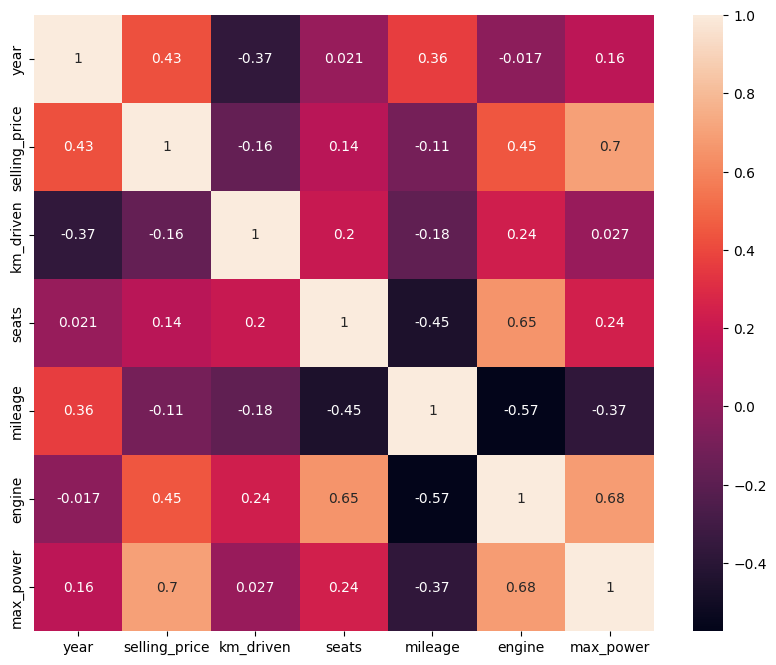

In [34]:
df_train = df_train_fixed_und.copy()

corr = df_train.corr(method='pearson', numeric_only=True)

plt.figure(figsize = (10, 8))
sns.heatmap(corr, annot=True)
plt.show()

In [35]:
df_train.describe(include='object')

,name,fuel,seller_type,transmission,owner
count,5840,5840,5840,5840,5840
unique,1924,4,3,2,5
top,Maruti Swift Dzire VDI,Diesel,Individual,Manual,First Owner
freq,91,3177,5223,5336,3603


In [36]:
df_train.describe(include='float')

,year,selling_price,km_driven,seats,mileage,engine,max_power
count,5840.000000,5.840000e+03,5.840000e+03,5840.000000,5654.000000,5654.000000,5656.000000
mean,2013.428425,5.229601e+05,7.395224e+04,5.440057,19.432842,1435.418111,88.103070
std,4.095622,5.354320e+05,6.007114e+04,0.979297,4.051002,492.453262,32.131943
min,1983.000000,2.999900e+04,1.000000e+00,2.000000,0.000000,624.000000,0.000000
25%,2011.000000,2.500000e+05,3.900000e+04,5.000000,16.800000,1197.000000,68.000000
50%,2014.000000,4.050000e+05,7.000000e+04,5.000000,19.370000,1248.000000,81.860000
75%,2017.000000,6.400000e+05,1.000000e+05,5.000000,22.320000,1498.000000,100.000000
max,2020.000000,1.000000e+07,2.360457e+06,14.000000,42.000000,3604.000000,400.000000


In [ ]:
# assert df_train.shape == (5840, 13)

## **Визуализации (1 балл + 0.5 бонус)**



Визуализация данных — важный шаг в работе. Визуализировать данные необходимо, например, чтобы:

- Оценить распределения признаков самих по себе (это может натоклнуть вас на мысли о модели, которую можно использовать)
- Сравнить распределения на `train` и `test` — чтобы проверить, насколько информация, на которой вы будете обучаться согласуется с той, на которой модель должна работать
- Оценить есть ли явная связь признаков с целевой переменной

**Важно:**

Если распределения на `train` и `test` не совпадают, это не значит, что нужно перемешивать данные! Более корректно актуализировать задачу и уточнить, а не устарели ли данные `train`. Также полезным может быть собрать новую тестовую выборку, смешав те, что имеются сейчас.

**Если вы будете подгонять распределения, то можете встретиться с переобучением!**

### **Задание 6 (0.5 балла)**

Шаг 1.
- [ ] Воспользуйтесь `pairplot` из библиотеки `seabron`, чтобы визуализировать попарные распределения числовых признаков для `train`
- [ ] По полученному графику ответьте на вопросы:
 - Можно ли предположить на основе распределений связь признаков с целевой переменной?
 - Можно ли предположить на основе распределений выдвинуть гипотезу о корреляциях признаков?

Шаг 2.

- [ ] Постройте pairplot по тестовым данным
- [ ] Ответьте на вопрос "Похожими ли оказались совокупности при разделении на трейн и тест?"

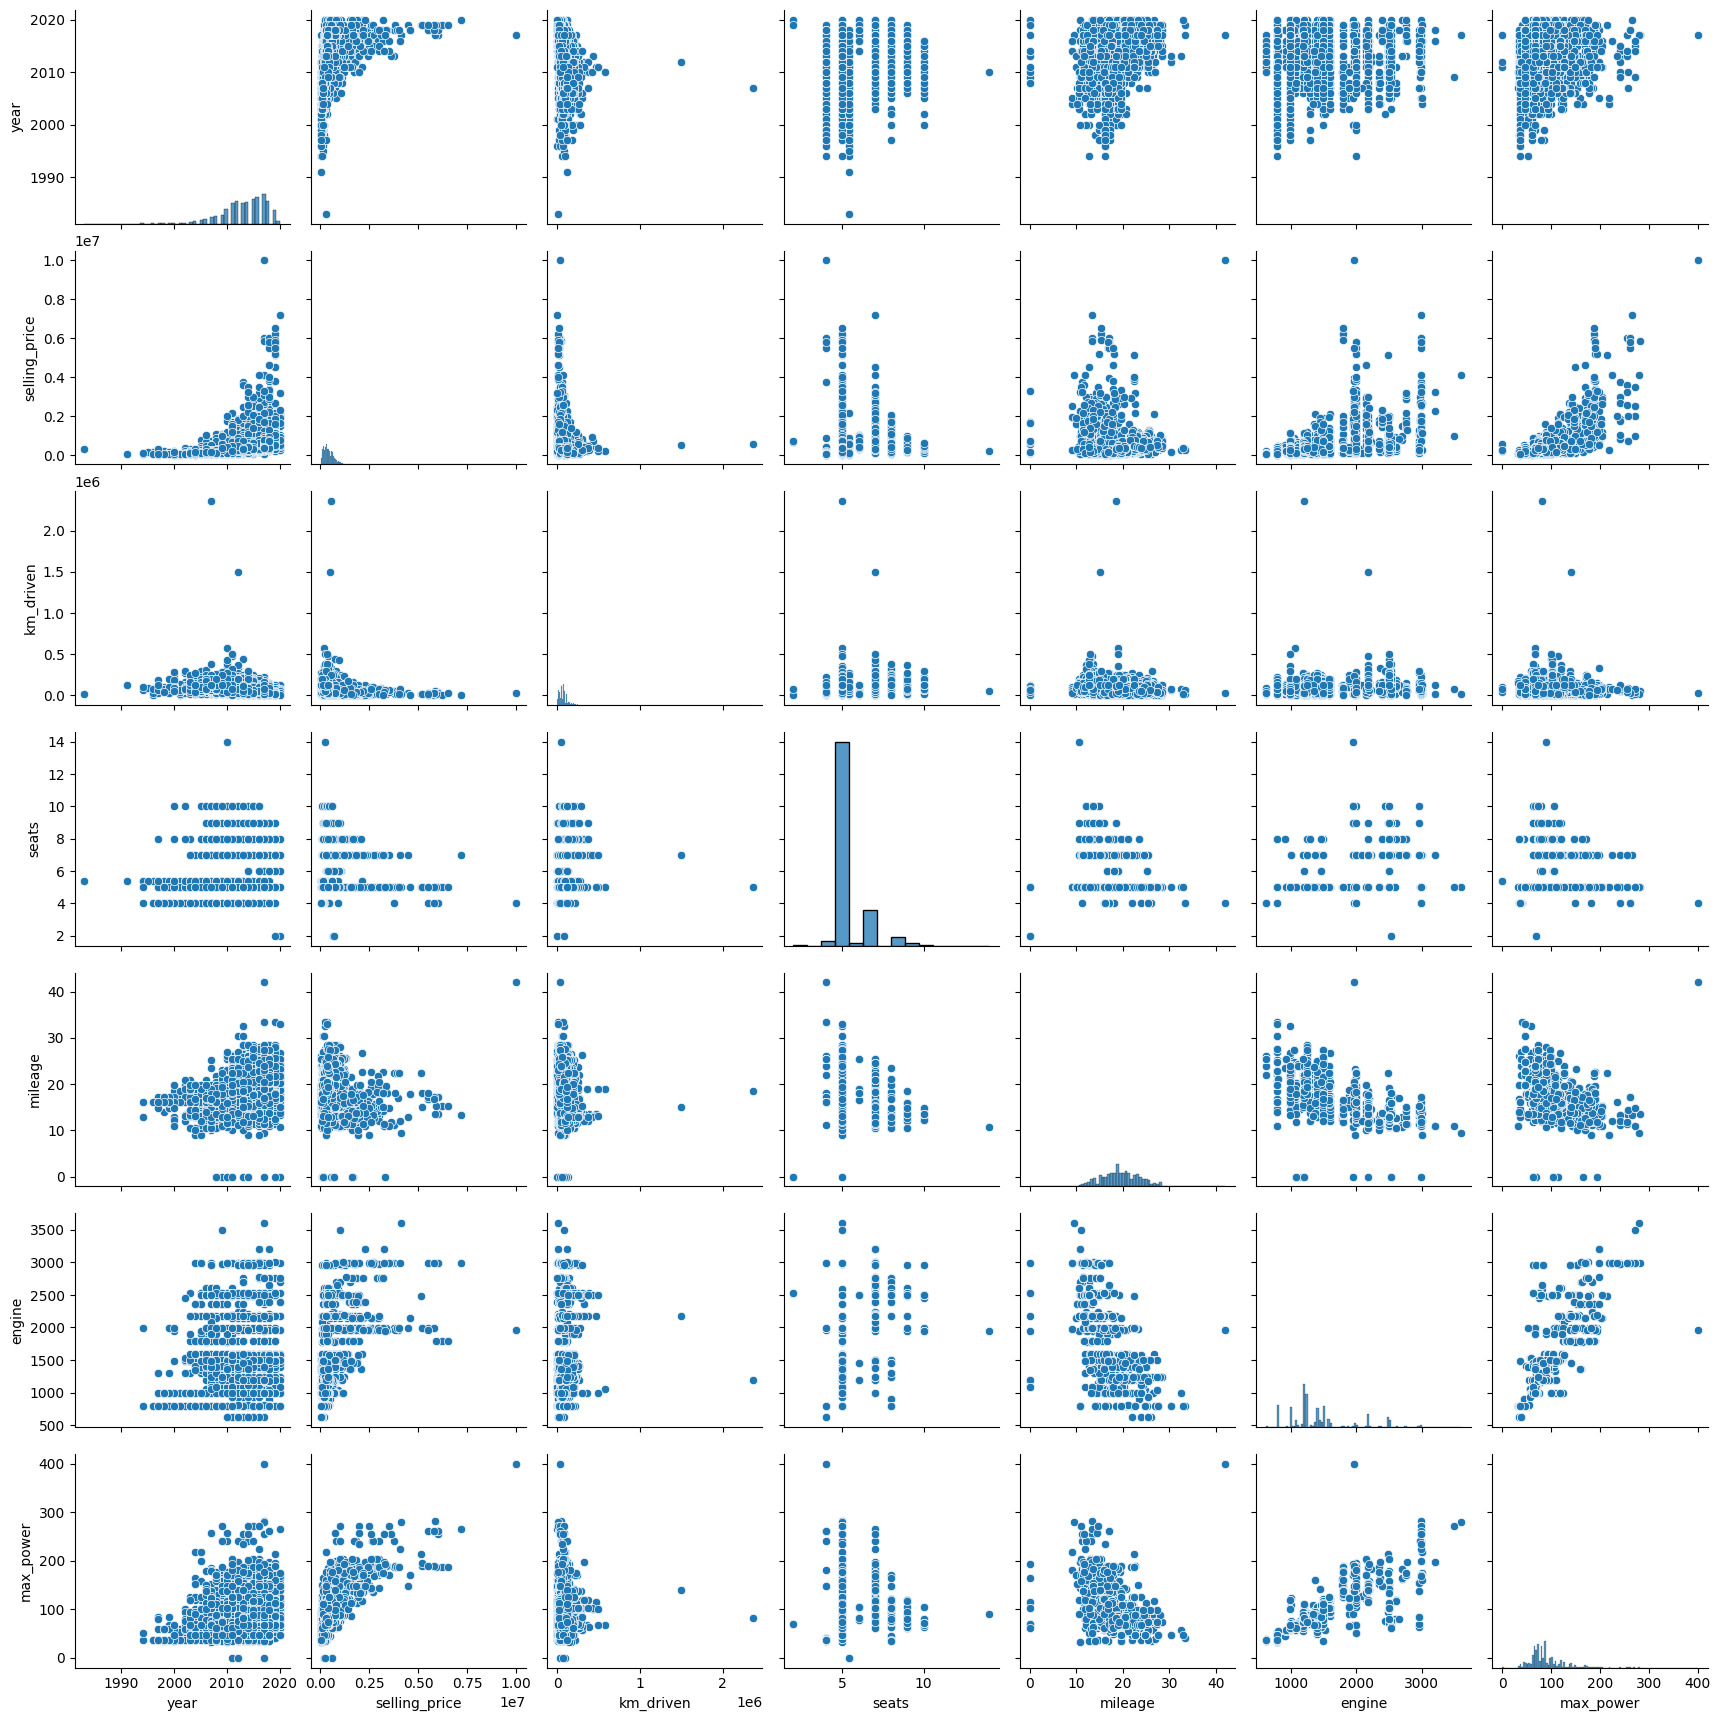

In [37]:
sns.pairplot(df_train)
plt.show()

# 1) да 2) да

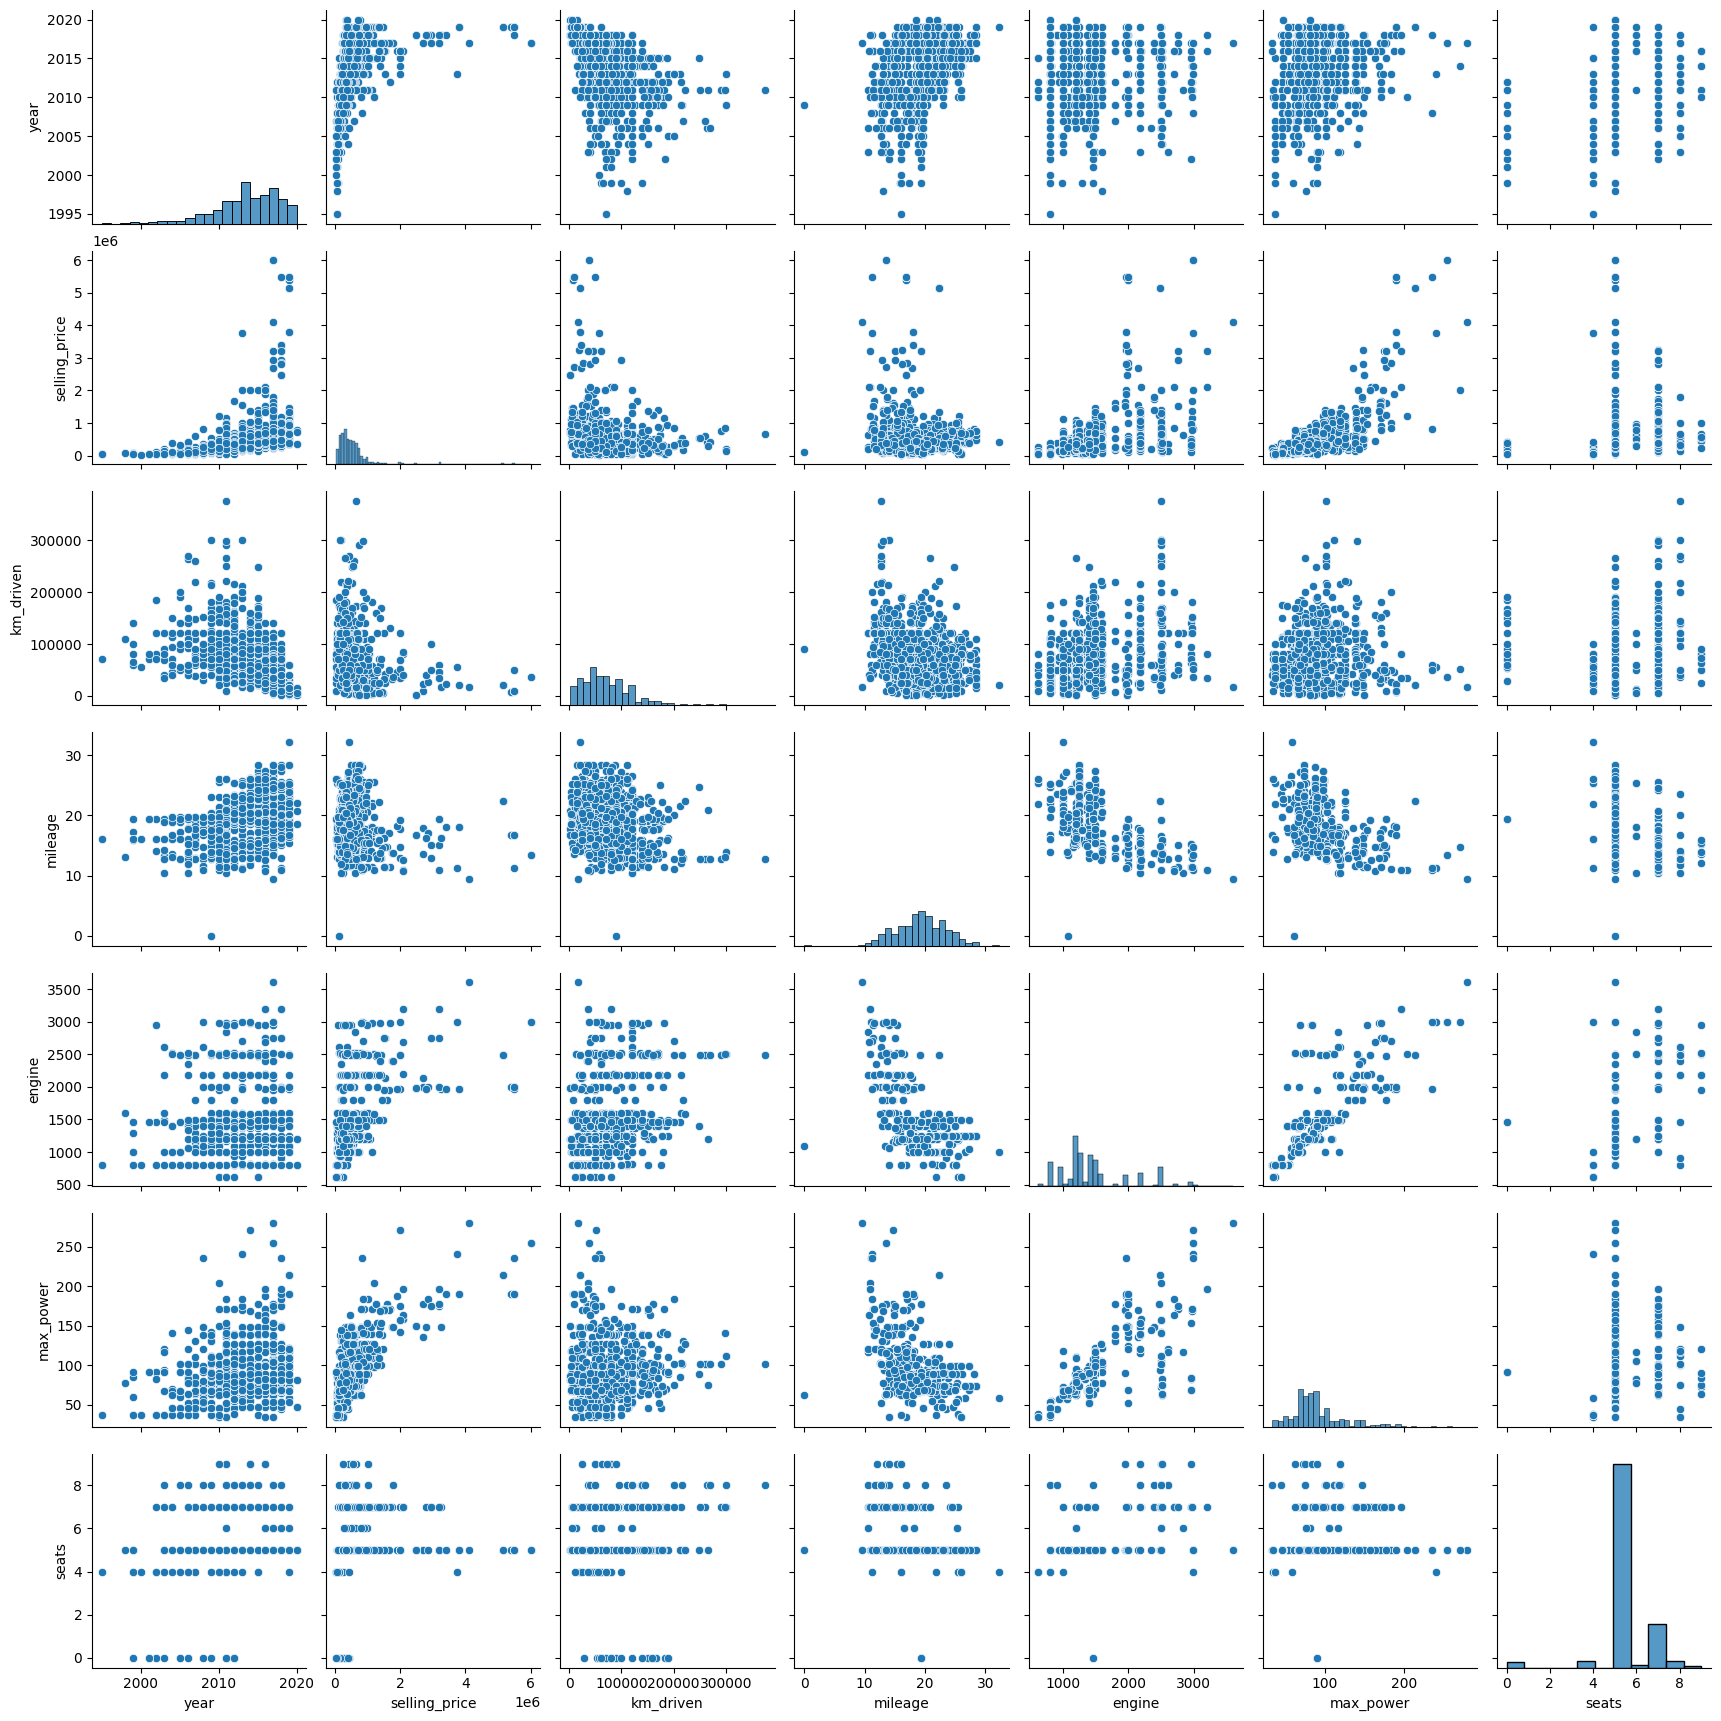

In [38]:
sns.pairplot(df_test)
plt.show()

### **Задание 7 (0.5 балла)**

И так, вы выдвинули гипотезы о наличии связи. Теперь давайте оценим эту связь в числах.

**Задание:**
- [ ] Получите значения коэффициента корреляции Пирсона для тренировочного набора данных при помощи `pd.corr()`
- [ ] По полученным корреляциям постройте тепловую карту (`heatmap` из бибилотеки seaborn)


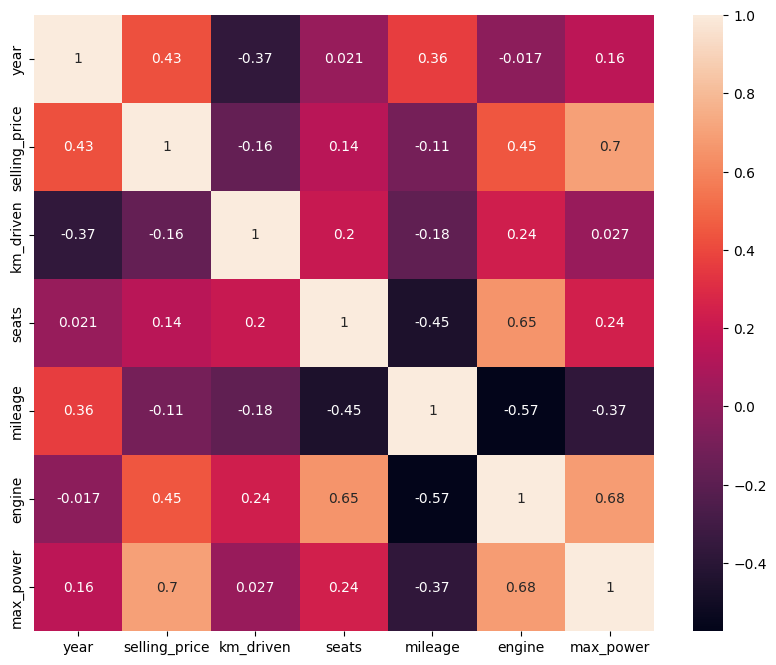

In [39]:
corr = df_train.corr(method='pearson', numeric_only=True)

plt.figure(figsize = (10, 8))
sns.heatmap(corr, annot=True)
plt.show()

- [ ] Ответьте на вопросы:
 - Какие 2 признака наименее скоррелированы между собой?
 - Между какими наблюдается довольно сильная положительная линейная зависимость?
 - Правильно ли, опираясь на данные, утверждать, что чем меньше год, тем, скорее всего, больше километров проехала машина к дате продажи?

1) Год и двигатель
2) Макс мощность и двигатель
3) Да


### **Бонус (0.5 балла)**

Если вам кажется, что мы не попросили вас нарисовать какие-то очень важные зависимости, нарисуйте их **и поясните.**

- Каждая дополнительная визуализация может принести до 0.25 баллов при условии, что она обоснована.

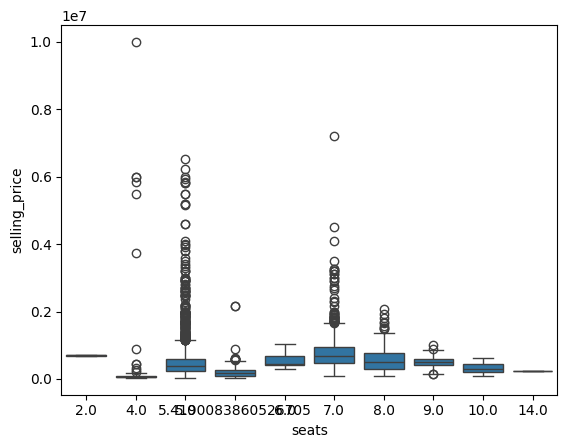

In [40]:
sns.boxplot(data=df_train, x="seats", y="selling_price")
plt.show()

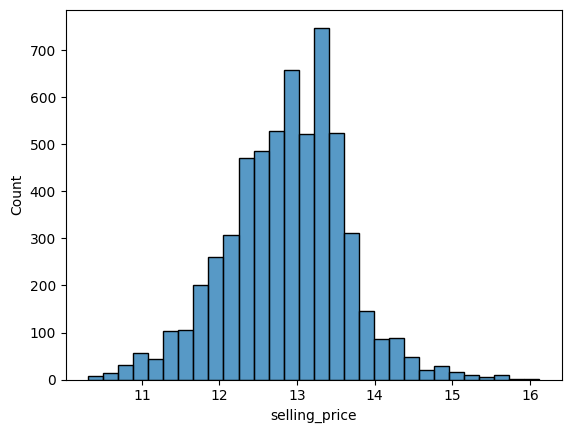

In [41]:
sns.histplot(np.log1p(df_train["selling_price"]), bins=30)
plt.show()

# **Часть 2 | Модель только на вещественных признаках**

В этой части вам предстоит обучить модель только на вещественных признаках. Почему только на них?

Чем больше признаковое пространство — чем сложнее модель. А чем модель проще — тем лучше для скорости работы и интерпретации признаков.

За задания этой части вы можете набрать 1.25 балла;

### **Задание 8 (0.05 балла)**

Сделайте тренировочный и тестовый наборы. Сделайте на тренировочный и тестовый наборы. Она уже даны, достаточно просто отделить целевой признак Перед разбиением создайте копию датафрейма, который будет хранить только вещественные признаки и используйте его (то есть категориальные столбцы (все, кроме seats) необходимо удалить).

В переменные y_train и y_test запишите значения целевых переменных. Используйте уже имеющиеся данные train и test при разбиении. Если считаете уместным применить какую-то более хитрую технику разбиения — примените, но опишите, зачем.

In [52]:
from sklearn.model_selection import train_test_split

mask_cat = (df_train.dtypes=='object').values

df_real = df_train[df_train.columns[~mask_cat]]
df_cat = df_train[df_train.columns[mask_cat]]

df_real_fixed = pd.DataFrame(data=mis_replacer.fit_transform(df_real), columns=df_real.columns)

df_train = pd.concat([df_real_fixed, df_cat], axis = 1)

cat_mask = (df_train.dtypes=='object').values
df_train_real = df_train[df_train.columns[~cat_mask]]

X = df_train_real.drop(columns=['selling_price'])
y = df_train_real['selling_price']

In [53]:
X.isna().sum()

,0
year,0
km_driven,0
seats,0
mileage,0
engine,0
max_power,0


In [54]:
y

,selling_price
0,450000.0
1,370000.0
2,225000.0
3,130000.0
4,440000.0
...,...
5835,120000.0
5836,260000.0
5837,320000.0
5838,135000.0


In [55]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

### **Задание 9 (0.2 балла)**

Построим нашу первую модель!
- [ ] Обучите классическую линейную регрессию с дефолтными параметрами. Посчтитайте $R^2$ и $MSE$ для трейна и для теста.
- [ ] Сделайте выводы по значениям метрик качества.

**Примечание:**

Здесь и далее $R^2$ и $MSE$ для трейна и для теста выводите везде, где требуется обучать модели, даже если в явном виде этого не просят. Иначе непонятно, как понять, насколько успешны наши эксперименты.

In [56]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error as MSE

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred_trained = model.predict(X_train)


In [57]:
print(r2_score(y_test, y_pred), 'R2')
print(MSE(y_test, y_pred), 'MSE')

0.5796054614685051 R2
141697011635.20084 MSE


In [58]:
print(r2_score(y_train, y_pred_trained), 'R2')
print(MSE(y_train, y_pred_trained), 'MSE')

0.5954452162409634 R2
110845497677.20506 MSE


### **Задание 10 (0.15 балла)**

Всегда есть место совершенству. Поэтому давайте попробуем улучшить модель. При помощи стандартизации признаков.

- [ ] Стандартизируйте значения в тренировочных и тестовых данных. Стандартизатор **обучайте только на `train`**.

In [67]:
from sklearn.preprocessing import StandardScaler

normalaser = StandardScaler()
normalaser.fit(X_train)

X_norm_train = pd.DataFrame(data = normalaser.transform(X_train))
X_norm_test = pd.DataFrame(data = normalaser.transform(X_test))


In [91]:
model = LinearRegression()
model.fit(X_norm_train, y_train)

y_pred = model.predict(X_norm_test)
y_pred_trained = model.predict(X_norm_train)

In [68]:
X_norm_train

,0,1,2,3,4,5
0,-0.339858,0.244127,-0.457303,-0.103975,-0.906257,-0.670097
1,-0.581718,-0.548149,-0.457303,-0.280830,1.139406,1.919756
2,0.143864,0.244127,-0.457303,1.664578,0.123785,0.339561
3,1.353166,-0.865059,-0.457303,0.224471,-0.492180,-0.134498
4,1.353166,-1.023514,-0.457303,0.502386,-0.496300,-0.157255
...,...,...,...,...,...,...
4667,0.869445,-1.102742,-0.457303,-0.129240,-0.496300,-0.197001
4668,1.111306,-0.548149,1.556830,-0.770972,1.526701,1.666540
4669,1.353166,-1.023514,-0.457303,0.350796,0.113484,0.813940
4670,0.143864,-0.500438,-0.457303,-0.134293,-0.904197,1.133504


In [92]:
print(r2_score(y_test, y_pred), 'R2 ')
print(MSE(y_test, y_pred), 'MSE')

print(r2_score(y_train, y_pred_trained), 'R2')
print(MSE(y_train, y_pred_trained), 'MSE')

0.5796054614685097 R2 
141697011635.19928 MSE
0.5954452162409635 R2
110845497677.20505 MSE


### **Задание 11 (0.1 балла)**

Хотя стандартизация не помогла сильно прибавить в качестве она открыла возможность интерпретировать важность признаков в модели. Правило интерпретации такое:

Чем больше коэффициент $\beta_i$ по модулю, тем важнее признак.

**Ответьте на вопрос:**

- [ ] Какой признак оказался наиболее информативным в предсказании цены?

In [71]:
model.coef_
# Мощность двигателя

array([155850.35257044, -40550.99071657, -15400.01787938,  32406.36392803,
        57724.52606957, 315081.98528467])

### **Задание 12 (0.25 балла)**

Попробуем улучшить нашу модель с помощью применения регуляризации. Для этого воспльзуемся `Lasso` регрессией.  Кроме того, попробуйте использовать её теоретическое свойство отбора признаков, за счет зануления незначимых коэффициентов.

**Задание:**

- [ ] Обучите Lasso регрессию на тренировочном наборе данных с нормализованными признаками. Оцените её качество
- [ ] Проверьте, занулила ли L1-регуляризация с параметрами по умолчанию какие-нибудь веса? Предположите почему.

In [101]:
from sklearn.linear_model import Lasso

model2 = Lasso(alpha=0.7)
model2.fit(X_norm_train, y_train)


In [102]:
y_pred = model2.predict(X_norm_test)
y_pred_trained = model2.predict(X_norm_train)

print(r2_score(y_test, y_pred), 'R2 ')
print(MSE(y_test, y_pred), 'MSE')
print(r2_score(y_train, y_pred_trained), 'R2')
print(MSE(y_train, y_pred_trained), 'MSE')

0.5796051182650674 R2 
141697127314.39508 MSE
0.595445216223786 R2
110845497681.91158 MSE


### **Задание 13 Финальный рывок (0.5 балла)**

До этого мы с вами использовали `train` для обучения и `test` для прогнозирования. Но у нас есть ещё одна задача — подобрать оптимальные параметры модели. Для этого используем кросс-валидацию, описанную на семинарах.

Кроме того, выжмем максимум из модификаций регрессии. Построим `ElasticNet`. И сделаем всё по порядку.

**Ваша задача 1:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для Lasso-регрессии. Вам пригодится класс [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html).
- [ ] Ответьте на вопросы:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какой коэффициент регуляризации у лучшей из перебранных моделей? Занулились ли какие-нибудь из весов при такой регуляризации?

In [117]:
from sklearn.model_selection import GridSearchCV

params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    estimator=Lasso(max_iter=10000),
    param_grid=params,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_norm_train, y_train)

GridSearchCV(cv=10, estimator=Lasso(max_iter=10000), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [128]:
best_model = grid.best_estimator_
grid.best_score_

np.float64(0.5902949490443687)

In [119]:
model.coef_

array([155850.35257044, -40550.99071657, -15400.01787938,  32406.36392803,
        57724.52606957, 315081.98528467])

In [120]:
y_pred = best_model.predict(X_norm_test)
y_pred_trained = best_model.predict(X_norm_train)

print(r2_score(y_test, y_pred), 'R2 ')
print(MSE(y_test, y_pred), 'MSE')
print(r2_score(y_train, y_pred_trained), 'R2')
print(MSE(y_train, y_pred_trained), 'MSE')

0.5795563636209609 R2 
141713560418.87207 MSE
0.595444876967238 R2
110845590636.09825 MSE


**Ваша задача 2:**

- [ ] Перебором по сетке (c 10-ю фолдами) подберите оптимальные параметры для [ElasticNet](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.ElasticNet.html) регрессии.
- [ ] Ответьте на вопрос:
 - Сколько грид-сёрчу пришлось обучать моделей?
 - Какие гиперпараметры соответствуют лучшей (по выбранной метрике качества) из перебранных моделей?

In [129]:
from sklearn.linear_model import ElasticNet

param_grid = {
    "alpha": np.logspace(-4, 4, 20),
    "l1_ratio": [0.1, 0.3, 0.5, 0.7, 0.9]
}

elastic_grid = GridSearchCV(
    estimator=ElasticNet(max_iter=100000),
    param_grid=param_grid,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

elastic_grid.fit(X_norm_train, y_train)

GridSearchCV(cv=10, estimator=ElasticNet(max_iter=100000), n_jobs=-1,
             param_grid={'alpha': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'l1_ratio': [0.1, 0.3, 0.5, 0.7, 0.9]},
             scoring='r2')

In [130]:
best_model2 = elastic_grid.best_estimator_
elastic_grid.best_score_

np.float64(0.5913727094187465)

In [131]:
y_pred = best_model2.predict(X_norm_test)
y_pred_trained = best_model2.predict(X_norm_train)

print(r2_score(y_test, y_pred), 'R2 ')
print(MSE(y_test, y_pred), 'MSE')
print(r2_score(y_train, y_pred_trained), 'R2')
print(MSE(y_train, y_pred_trained), 'MSE')

0.5767166970257087 R2 
142670690528.10968 MSE
0.5945200045524156 R2
111098999932.50142 MSE


# **Часть 3| Добавляем категориальные фичи**

Попробуем для улучшения модели дать ей больше признаков. Добавим категориальные фичи.

За эту часть можно набрать 0.75 основных балла и 0.25 бонусных.


**Задание 14 (0.1 балла)** Проанализируйте столбец `name`. Очевидно, что эта переменная является категориальной, однако категорий в ней много.

В этом домашнем задании мы предлагаем удалить его.

**Ваша задача:**
- [ ] Удалить столбец`name`

In [134]:
df_train.drop(columns='name', inplace=True)

KeyError: "['name'] not found in axis"

В другом случае, конечно, мы могли бы предобработать данный столбец. В качестве бонуса предлагаем вам придумать и реализовать алгоритм предобработки.

**Бонус 0.25 балла**
- [ ] Предобработайте столбец `name`, чтобы избежать его удаления. Если предобработали столбец — можно закомментировать assert

In [135]:
# Разбить на категории марок через split()[0]. Делать лень

In [ ]:
X_train_cat.describe(include='object')

### **Задание 15 (0.4 балла)**

- [ ] Закодируйте категориалльные фичи и ``seats`` методом OneHot-кодирования. Обратите внимание, что во избежание мультиколлинеарности следует избавиться от одного из полученных столбцов при кодировании каждого признака методом OneHot.

In [ ]:
from sklearn.preprocessing import OneHotEncoder # или можно использовать get_dummies из библиотеки pandas

# your code here

### **Задание 16 (0.25 балла)**
Повторим то, что делали на прошлом шаге для моделей на вещественных признаках, однако теперь с моделью `Ridge`.


**Ваша задача:**
- [ ] Переберите параметр регуляризации `alpha` для гребневой (ridge) регрессии с помощью класса `GridSearchCV` В качестве параметров при объявлении GridSearchCV кроме модели укажите метрику качества $R^2$. Кроссвалидируйтесь по 10-ти фолдам.
- [ ] Ответье на вопрос: Удалось ли улучшить качество прогнозов?

In [138]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV

params = {
    "alpha": [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]
}

grid_ridge = GridSearchCV(
    estimator=Ridge(max_iter=10000),
    param_grid=params,
    cv=10,
    scoring="r2",
    n_jobs=-1
)

grid.fit(X_norm_train, y_train)

GridSearchCV(cv=10, estimator=Lasso(max_iter=10000), n_jobs=-1,
             param_grid={'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100]},
             scoring='r2')

In [139]:
best_model3 = grid.best_estimator_
grid.best_score_

np.float64(0.5902949490443687)

In [140]:
y_pred = best_model3.predict(X_norm_test)
y_pred_trained = best_model3.predict(X_norm_train)

print(r2_score(y_test, y_pred), 'R2 ')
print(MSE(y_test, y_pred), 'MSE')
print(r2_score(y_train, y_pred_trained), 'R2')
print(MSE(y_train, y_pred_trained), 'MSE')

0.5795563636209609 R2 
141713560418.87207 MSE
0.595444876967238 R2
110845590636.09825 MSE


# **Часть 4. | Бизнесовая (0.5 балла)**

### **Задание 17 (0.5 балла)**

В мире бизнеса очень важно давать оценку качества модели понятную бизнесу, поэтому иногда заказчики приходят с кастомными метриками. Попробуем сделать такую для нашей задачи.

**Описание метрики:**

Среди всех предсказанных цен на авто нужно посчитать долю прогнозов, отличающихся от реальных цен на эти авто не более чем на 10% (в одну или другую сторону)

**Ваша задача:**

- [ ] Реализуйте метрику `business_metric`
- [ ] Посчитайте метрику для всех обученных моделей и определеите, какая лучше всего решает задачу бизнеса

In [141]:
def business_metric(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    relative_error = np.abs(y_pred - y_true) / np.abs(y_true)
    return np.mean(relative_error <= 0.1)

In [144]:
linear_pred = model.predict(X_norm_test)
lasso_pred = best_model.predict(X_norm_test)
elastic_pred = best_model2.predict(X_norm_test)
rigge_pred = best_model3.predict(X_norm_test)

linear_business = business_metric(y_test, linear_pred)
lasso_business = business_metric(y_test, lasso_pred)
elastic_business = business_metric(y_test, elastic_pred)
rigge_business = business_metric(y_test, rigge_pred)

print("LinearRegression:", linear_business)
print("Lasso:", lasso_business)
print("ElasticNet:", elastic_business)
print("Rigge:", rigge_business)

LinearRegression: 0.21575342465753425
Lasso: 0.2166095890410959
ElasticNet: 0.2226027397260274
Rigge: 0.2166095890410959


`Your answer here`

# **<font color="green">Часть 5 | Создание интерактивного приложения на Streamlit (3 балла)</font>**

Вам необходимо создать интерактивное приложение на Streamlit, которое будет:

- Показывать основные информативные графики/гистограммы в рамках EDA (1 балл)
- На вход запрашивать csv-файл с признаками объектов или запрашивать признаки объекта в окошках для ввода, и применять на поступивших объектах модель (1 балл)
- Визуализировать веса обученной модели (1 балл)

# **Часть 6 | Оформление репозитория и оценка сервиса (2 балла)**

**Результаты вашей работы** необходимо разместить в своём GitHub-репозитории. В этот же репозиторий позже будет добавлена вторая часть.

Под результатами первой части понимаем следующее:

---

### Обязательные файлы:

1. **`.ipynb`-ноутбук** со всеми экспериментами:

   * полный EDA,
   * все шаги препроцессинга,
   * обучение и сравнение моделей,
   * сохранённые output’ы.

2. **`.pickle`-файл**, содержащий:

   * обученную модель (или пайплайн `scaler + model`);
   * параметры скейлинга;
   * любые числовые объекты, необходимые для инференса внутри Streamlit-приложения.

3. **`.md`-файл с выводами** о проделанной работе:

   * что было сделано (краткое описание каждого этапа);
   * какие результаты были получены (метрики + интерпретация);
   * что дало наибольший прирост качества;
   * что сделать не удалось и почему (это нормально и даже полезно);
   * **оценка разработанного сервиса**:

     * насколько приложение удобно в использовании;
     * что получилось визуализировать хорошо, а что — менее удачно;
     * какие ограничения или проблемы вы заметили;
     * какие улучшения планируете в следующей итерации.

По результатам второй части, ждем:

4. **Streamlit-приложение** (например, `app.py`), которое можно запустить командой:

   ```bash
   streamlit run app.py
   ```

**И ссылку на приложение в StreamlitHub.**

В приложении должно быть:

* отображение ключевых графиков EDA;
* ввод данных (CSV или ручной ввод);
* применение модели;
* визуализация весов/коэффициентов.



### **За что могут быть сняты баллы:**

* отсутствие `.pickle` с моделью / пайплайном;
* слабая или неполная аналитика в `.md`-файле;
* беспорядок в ноутбуке или неясная логика вычислений;
* отсутствие возможности запустить Streamlit-приложение.